## 0. Подключение библиотек.

In [230]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

## 1. Подготовка датасета LEGO наборов.

In [231]:
df = pd.read_csv('lego-sets.csv', sep=';')
df = df.rename(columns={'Subtheme':'subtheme','Pieces':'pieces','Year':'release_year',
    'Retail price':'retail_price',
    'avg_year':'avg_year',
    'avg_price':'avg_price'})

In [232]:
df = df.sort_values(['name','avg_year']).reset_index(drop=True)
df['next_avg_price'] = df.groupby('name')['avg_price'].shift(-1)
df = df.dropna(subset=['next_avg_price']).reset_index(drop=True)

In [233]:
df.head(10)

,name,theme,subtheme,pieces,minifigs,release_year,retail_price,avg_year,avg_price,next_avg_price
0,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2015,99.99,1481.68
1,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2016,1481.68,1281.40
2,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2017,1281.40,1319.69
3,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2018,1319.69,1351.93
4,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2019,1351.93,1728.84
5,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2020,1728.84,3289.34
6,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2021,3289.34,6602.94
7,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2022,6602.94,8463.12
8,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2023,8463.12,8576.35
9,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99,2024,8576.35,8890.74


## 2. Графики

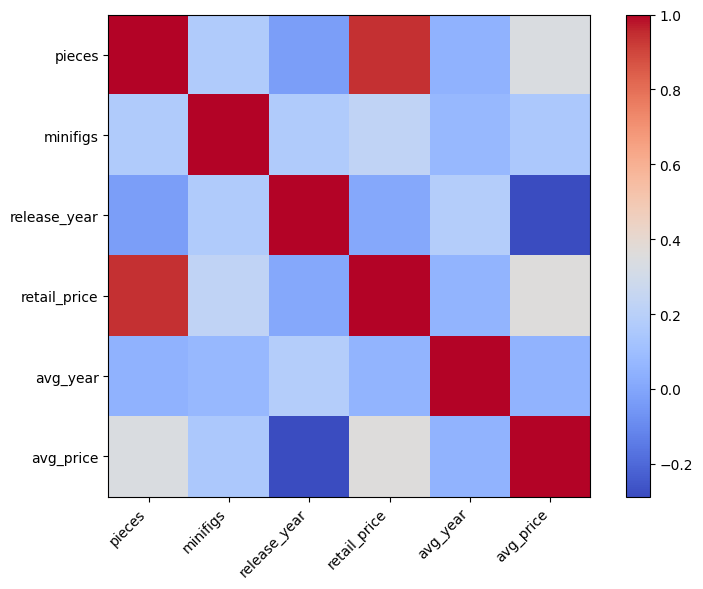

In [234]:
featuresMatrix = ['pieces', 'minifigs', 'release_year', 'retail_price', 'avg_year', 'avg_price']
corr = df[featuresMatrix].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(np.arange(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

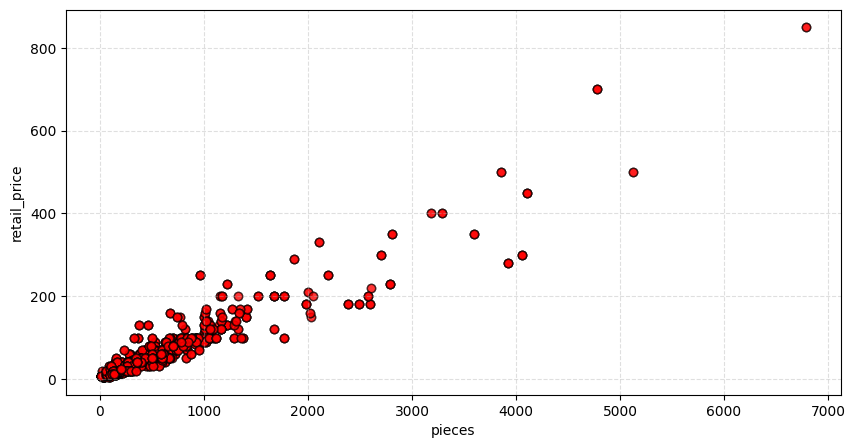

In [235]:
plt.figure(figsize=(10,5))
plt.scatter(df['pieces'], df['retail_price'], alpha=0.4, color='red', edgecolor='black')
plt.xlabel('pieces')
plt.ylabel('retail_price')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

## 3. Baseline

In [236]:
def smape(yBaseline, yPred):
    return 100 * np.mean(2 * np.abs(yPred - yBaseline) / (np.abs(yBaseline) + np.abs(yPred)))

df['pred_price'] = df.groupby('subtheme')['avg_price'].transform('mean')
pred_y = df['pred_price'].copy()
baseline_y = df['next_avg_price'].copy()
maeBaseline = mean_absolute_error(pred_y, baseline_y)
mseBaseline = mean_squared_error(df['next_avg_price'], df['pred_price'])
smapeBaseline = smape(df['next_avg_price'], df['pred_price'])
print("MAE", round(maeBaseline, 2))
print("MSE", round(mseBaseline, 2))
print("SMAPE", round(smapeBaseline, 2))

MAE 83.14
MSE 103638.41
SMAPE 62.02


## 4. Линейная регрессия.

### 4.1  One-hot Encoding

In [237]:
def one_hot_category(df, categoryCols):
    category = pd.unique(pd.concat([df[c].dropna().astype(str)
    for c in categoryCols], ignore_index=True))
    idx_map = {cat: i for i, cat in enumerate(category)}

    m = np.zeros((len(df), len(category)), dtype=np.uint8)

    for r, row in df[categoryCols].iterrows():
        for c in categoryCols:
            value = row[c]
            if pd.notna(value):
                m[r, idx_map[str(value)]] = 1

    return pd.DataFrame(m, columns=[f"category_{cat}" for cat in category], index=df.index)
one_hot = one_hot_category(df, ['theme', 'subtheme'])

In [238]:
data_x = pd.concat([df[["avg_price", "retail_price", "pieces", "release_year", "minifigs", "avg_year", "avg_price"]], one_hot], axis=1)
data_x.head(10)

,avg_price,retail_price,pieces,release_year,minifigs,avg_year,avg_price,category_Star Wars,category_Harry Potter,category_Speed Champions,...,category_Mini,category_Goblet of Fire,category_Fantastic Beasts,category_Characters Sculptures,category_Hogwarts Moments,category_Nissan,category_Jaguar,category_Toyota,category_Lotus,category_Magazine Gifts
0,99.99,99.99,698,2003,7,2015,99.99,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1481.68,99.99,698,2003,7,2016,1481.68,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1281.40,99.99,698,2003,7,2017,1281.40,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1319.69,99.99,698,2003,7,2018,1319.69,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1351.93,99.99,698,2003,7,2019,1351.93,1,0,0,...,0,0,0,0,0,0,0,0,0,0
5,1728.84,99.99,698,2003,7,2020,1728.84,1,0,0,...,0,0,0,0,0,0,0,0,0,0
6,3289.34,99.99,698,2003,7,2021,3289.34,1,0,0,...,0,0,0,0,0,0,0,0,0,0
7,6602.94,99.99,698,2003,7,2022,6602.94,1,0,0,...,0,0,0,0,0,0,0,0,0,0
8,8463.12,99.99,698,2003,7,2023,8463.12,1,0,0,...,0,0,0,0,0,0,0,0,0,0
9,8576.35,99.99,698,2003,7,2024,8576.35,1,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.2 Разделение на train, val, test.

In [239]:
order = df['avg_year'].sort_values().index
dataX_Sort = data_x.loc[order].reset_index(drop=True)
dataY_Sort = df.loc[order, 'next_avg_price'].reset_index(drop=True)
mas = len(dataX_Sort)

value_train = int(0.7 * mas)
value_valid = int(0.85 * mas)

trainData_X = dataX_Sort.iloc[:value_train]
validationData_X = dataX_Sort.iloc[value_train:value_valid]
testData_X = dataX_Sort.iloc[value_valid:]
trainData_Y = dataY_Sort.iloc[:value_train]
validationData_Y = dataY_Sort.iloc[value_train:value_valid]
testData_Y = dataY_Sort.iloc[value_valid:]

print(len(trainData_X))
print(len(validationData_X))
print(len(testData_X))
print(trainData_X.shape)

1950
418
418
(1950, 88)


In [240]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(trainData_X)
val_scaled = scaler.transform(validationData_X)
test_scaled = scaler.transform(testData_X)
df = df[df['next_avg_price'] < df['next_avg_price'].quantile(0.99)]


### 4.3 Обучение модели.

In [242]:
model = LinearRegression()
model.fit(trainData_X, trainData_Y)

LinearRegression()

In [243]:
trainPrediction = model.predict(trainData_X)
maeTrain = mean_absolute_error(trainData_Y, trainPrediction)
mseTrain = mean_squared_error(trainData_Y, trainPrediction)
smapeTrain = smape(trainData_Y, trainPrediction)
print(f"MAE (Train) {maeTrain:.2f}")
print(f"MSE (Train) {mseTrain:.2f}")
print(f"SMAPE (Train) {smapeTrain:.2f}")
print()

validationPrediction = model.predict(validationData_X)
maeValidation = mean_absolute_error(validationData_Y, validationPrediction)
mseValidation = mean_squared_error(validationData_Y, validationPrediction)
smapeValidation = smape(validationData_Y, validationPrediction)
print(f"MAE (Validation) {maeValidation:.2f}")
print(f"MSE (Validation) {mseValidation:.2f}")
print(f"SMAPE (Validation) {smapeValidation:.2f}")
print()

testPrediction = model.predict(testData_X)
maeTest = mean_absolute_error(testData_Y, testPrediction)
mseTest = mean_squared_error(testData_Y, testPrediction)
smapeTest = smape(testData_Y, testPrediction)
print(f"MAE (Test) {maeTest:.2f}")
print(f"MSE (Test) {mseTest:.2f}")
print(f"SMAPE (Test): {smapeTest:.2f}")

MAE (Train) 23.20
MSE (Train) 7884.58
SMAPE (Train) 32.80

MAE (Validation) 21.00
MSE (Validation) 4100.96
SMAPE (Validation) 39.17

MAE (Test) 17.28
MSE (Test) 588.57
SMAPE (Test): 41.55


### 4.4 Перебор гиперпараметров.

In [244]:
GRID = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 5, 10]}

lasso = Lasso(random_state=30, max_iter=2000)
L1 = GridSearchCV(lasso, GRID,scoring='neg_mean_absolute_error',cv=5,n_jobs=-1,verbose=1)
L1.fit(trainData_X, trainData_Y)
print("alpha", L1.best_params_['alpha'])
print("MAE (CV)", -L1.best_score_)

resultLasso = L1.best_estimator_
trainPredictionL1 = L1.predict(trainData_X)
validationPredictionL1 = L1.predict(validationData_X)
testPredictionL1 = L1.predict(testData_X)

maeTrainL1 = mean_absolute_error(trainData_Y, trainPredictionL1)
maeValidationL1 = mean_absolute_error(validationData_Y, validationPredictionL1)
maeTestL1 = mean_absolute_error(testData_Y, testPredictionL1)
smapeTrainL1 = smape(trainData_Y, trainPredictionL1)
smapeValidationL1 = smape(validationData_Y, validationPredictionL1)
smapeTestL1 = smape(testData_Y, testPredictionL1)
print(f"MAE (Train) {maeTrainL1:.2f}")
print(f"MAE (Validation) {maeValidationL1:.2f}")
print(f"MAE (Test) {maeTestL1:.2f}")
print(f"SMAPE (Train) {smapeTrainL1:.2f}")
print(f"SMAPE (Validation) {smapeValidationL1:.2f}")
print(f"SMAPE (Test) {smapeTestL1:.2f}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
alpha 10
MAE (CV) 22.897122295244156
MAE (Train) 19.25
MAE (Validation) 16.89
MAE (Test) 10.94
SMAPE (Train) 17.11
SMAPE (Validation) 13.64
SMAPE (Test) 10.64


/tmp/ipython-input-2507455043.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


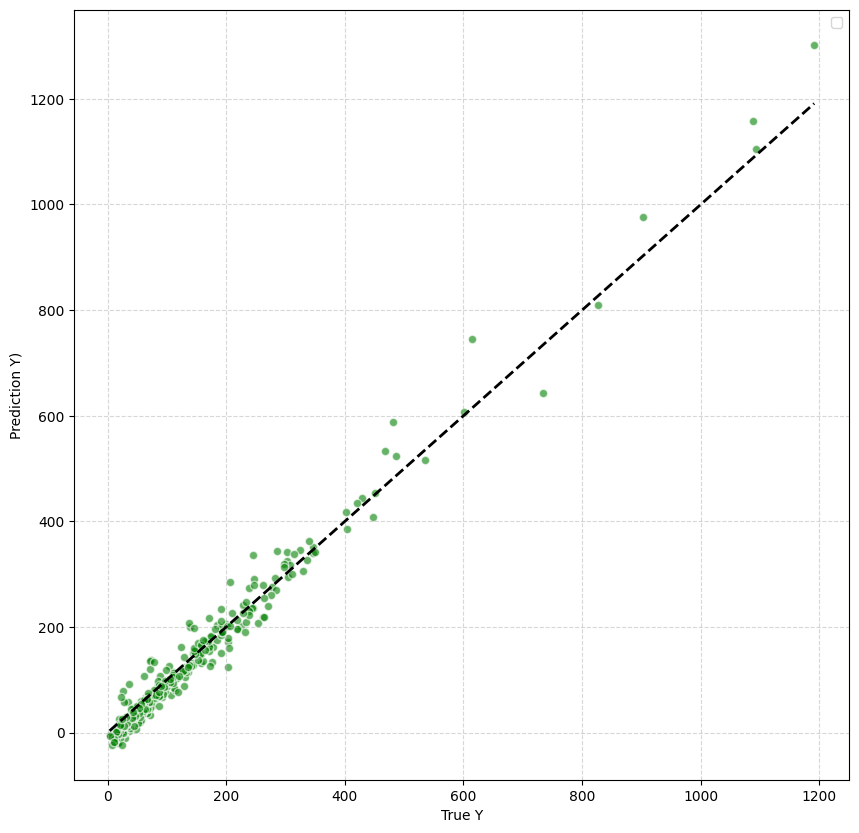

In [289]:
plt.figure(figsize=(10,10))
plt.scatter(testData_Y, testPrediction, alpha=0.6, color='green', edgecolors='white')
plt.plot([testData_Y.min(), testData_Y.max()],[testData_Y.min(), testData_Y.max()],color='black', linestyle='--', lw=2)
plt.xlabel("True Y")
plt.ylabel("Prediction Y)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 5. Реализация линейной регрессии.

In [272]:
def myLineRegression(trainData_X, trainData_Y, l, standardize):
  trainData_X_matrix = trainData_X.to_numpy(dtype=float)
  trainData_Y_matrix = trainData_Y.to_numpy(dtype=float)
  column_one = np.ones((trainData_X_matrix.shape[0], 1))
  trainData_X_matrix = np.hstack([column_one, trainData_X_matrix])

  if standardize:
      mean = trainData_X_matrix[:, 1:].mean(axis=0)
      std = trainData_X_matrix[:, 1:].std(axis=0)
      std[std == 0] = 1
      trainData_X_matrix[:, 1:] = (trainData_X_matrix[:, 1:] - mean) / std


  transpose_trainData_X_matrix = (trainData_X_matrix.T)
  mult_trainData_X_matrix = np.dot(transpose_trainData_X_matrix, trainData_X_matrix)
  matrixI = np.eye(mult_trainData_X_matrix.shape[0])
  matrixI[0, 0] = 0
  inverse_trainData_X_matrix = np.linalg.pinv(mult_trainData_X_matrix + l * matrixI)

  alpha_matrix = np.dot(np.dot(inverse_trainData_X_matrix, transpose_trainData_X_matrix), (trainData_Y_matrix))
  yPrediction = np.dot(trainData_X_matrix, alpha_matrix)
  return yPrediction

In [286]:
lambdas = [0, 1, 0.5, 0.1, 0.3, 0.25]
standardizes = [0,1]
minMAE = 100
lambdas_standardizes = None
for lambd in lambdas:
  for stand in standardizes:
    my_Y_Predction = myLineRegression(trainData_X, trainData_Y, lambd, stand)
    maeYPrediction = mean_absolute_error(my_Y_Predction, trainData_Y)
    if minMAE > maeYPrediction:
      minMAE = maeYPrediction
      lambdas_standardizes = (lambd, stand)
print(round(maeYPrediction,2))
print(lambd,stand)
print(minMAE)

23.2
0.25 1
23.077078958442062


/tmp/ipython-input-618017390.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


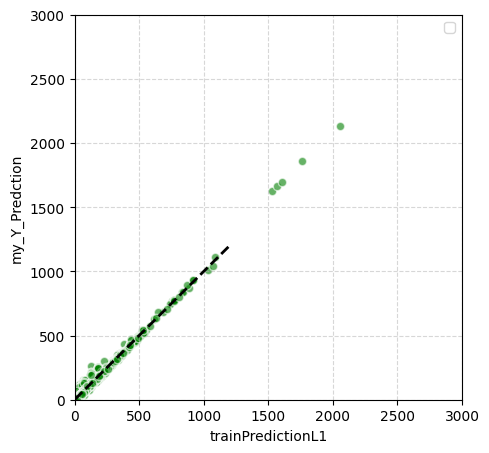

In [295]:
my_Y_Predction = myLineRegression(trainData_X, trainData_Y, 0.25, 1)
plt.figure(figsize=(5,5))
plt.scatter(trainPredictionL1, my_Y_Predction, alpha=0.6, color='green', edgecolors='white')
plt.plot([testData_Y.min(), testData_Y.max()],[testData_Y.min(), testData_Y.max()],color='black', linestyle='--', lw=2)
plt.xlabel("trainPredictionL1")
plt.ylabel("my_Y_Predction")
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()